In [2]:
import pandas as pd

df = pd.read_csv("group_stroke.csv", sep=";")
df = df.drop(columns=['Unnamed: 4'])
df.columns = ["status_stroke", "jenis_kelamin", "usia", "total"]

for col in ["status_stroke", "jenis_kelamin", "usia"]:
    df[col] = df[col].astype(str).str.strip()

df["total"] = pd.to_numeric(df["total"], errors="coerce")

In [3]:
tabel_ringkas = df.pivot_table(
    index="usia",
    columns=["status_stroke", "jenis_kelamin"],
    values="total",
    aggfunc="sum"
)

print(tabel_ringkas)


status_stroke    Normal           Risiko Stroke            nan
jenis_kelamin Laki-Laki Perempuan     Laki-Laki Perempuan  nan
usia                                                          
18-24            1625.0    1724.0          11.0       4.0  NaN
25-29            2554.0    2653.0          27.0      16.0  NaN
30-34            2257.0    2503.0         660.0     475.0  NaN
35-39            1979.0    2134.0         782.0     666.0  NaN
40-44            1311.0    1561.0        1113.0     824.0  NaN
45-49             626.0    1015.0        1238.0     822.0  NaN
50-54              16.0     136.0        1412.0    1251.0  NaN
55-59               NaN      19.0         914.0     786.0  NaN
60-64               NaN       NaN         517.0     487.0  NaN
65-69               NaN       NaN         267.0     311.0  NaN
70-74               NaN       NaN         130.0     103.0  NaN
75-79               NaN       NaN          30.0      29.0  NaN
80+                 NaN       NaN           3.0       9

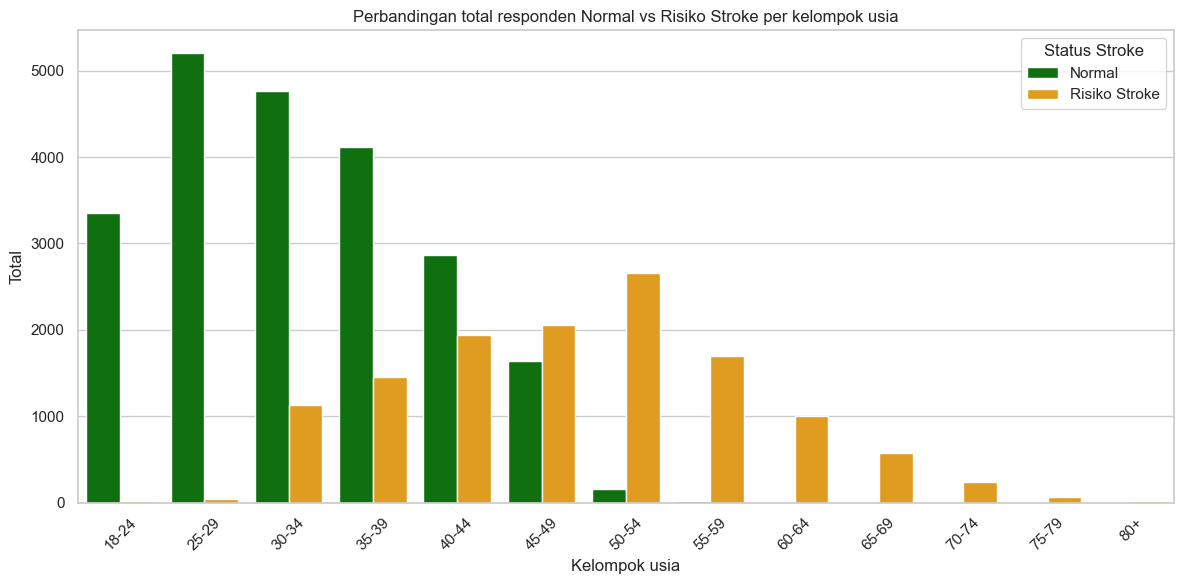

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Hapus NaN dulu kalau masih ada
df = df.dropna(subset=["usia", "status_stroke", "total"])

# Agregat total per usia dan status stroke
df_agg = df.groupby(["usia", "status_stroke"])["total"].sum().reset_index()

# Set warna manual: Normal = hijau, Risiko Stroke = oranye
palette = {
    "Normal": "green",
    "Risiko Stroke": "orange"
}

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_agg,
    x="usia",
    y="total",
    hue="status_stroke",
    palette=palette
)
plt.title("Perbandingan total responden Normal vs Risiko Stroke per kelompok usia")
plt.xlabel("Kelompok usia")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.legend(title="Status Stroke")
plt.tight_layout()
plt.show()


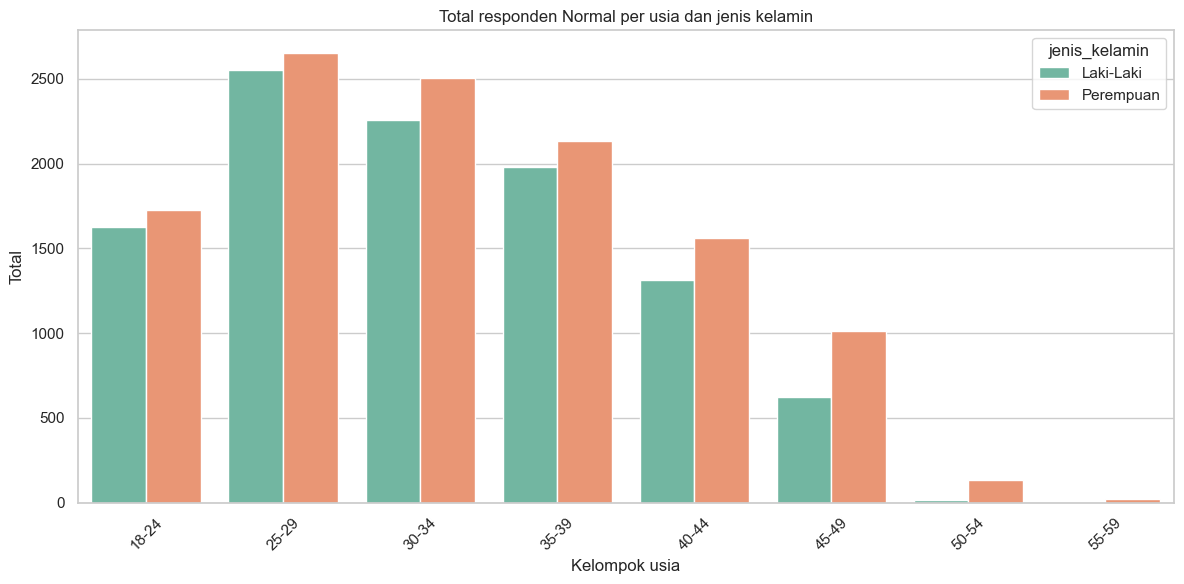

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Filter data untuk status stroke Normal
df_normal = df[df['status_stroke'] == 'Normal']

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_normal,
    x="usia",
    y="total",
    hue="jenis_kelamin",
    palette="Set2"
)
plt.title("Total responden Normal per usia dan jenis kelamin")
plt.xlabel("Kelompok usia")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

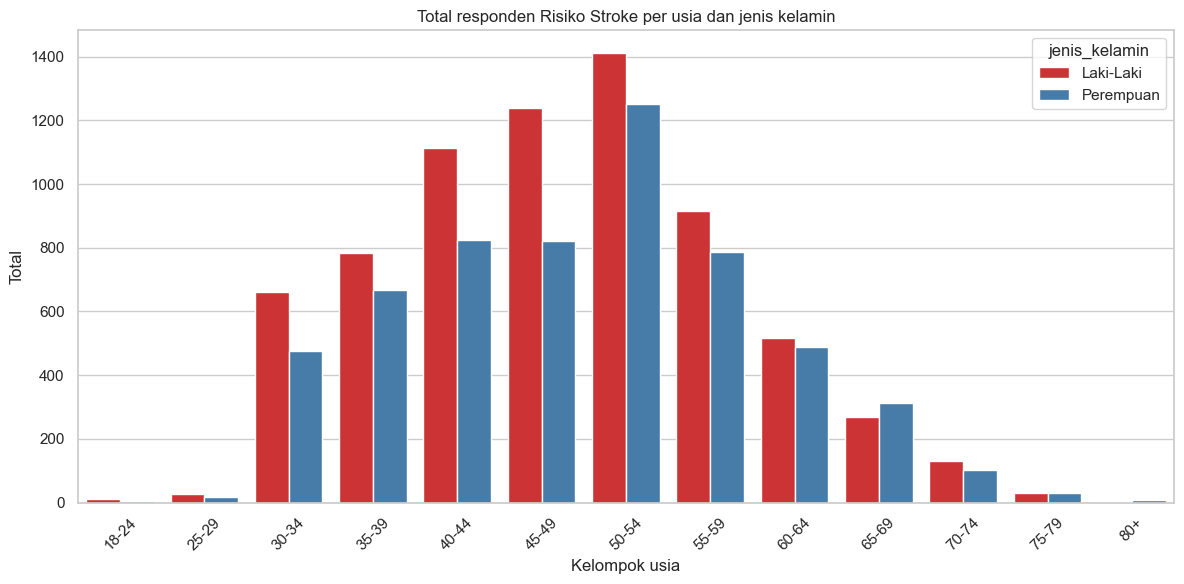

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# Filter data untuk status stroke Risiko Stroke
df_risiko = df[df['status_stroke'] == 'Risiko Stroke']

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_risiko,
    x="usia",
    y="total",
    hue="jenis_kelamin",
    palette="Set1"
)
plt.title("Total responden Risiko Stroke per usia dan jenis kelamin")
plt.xlabel("Kelompok usia")
plt.ylabel("Total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

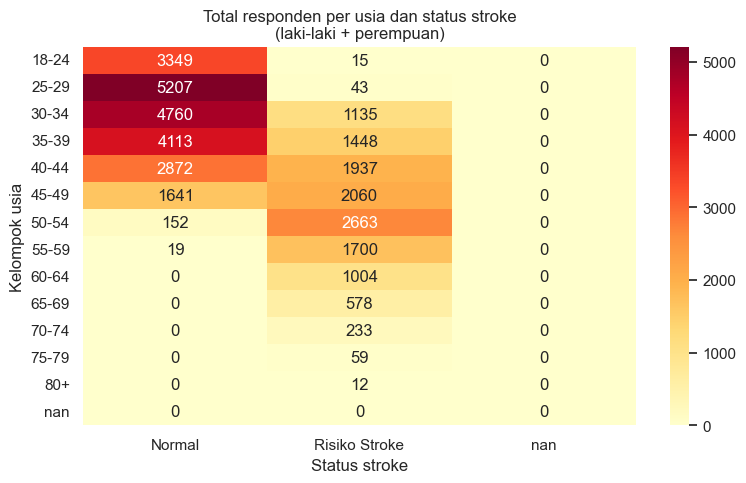

In [7]:
pivot_status_usia = df.pivot_table(
    index="usia",
    columns="status_stroke",
    values="total",
    aggfunc="sum",
    fill_value=0
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot_status_usia, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Total responden per usia dan status stroke\n(laki-laki + perempuan)")
plt.xlabel("Status stroke")
plt.ylabel("Kelompok usia")
plt.tight_layout()
plt.show()
